# K-Means Clustering

Note: I wanted the performance of my algorithm to be comparable to that of the scikit-learn package, which uses K++, so my implementation of this algorithm uses K++.

K-Means is an unsupervised learning algorithm that partitions data into a fixed number (k) of clusters based on feature similarity. It works by minimizing the within-cluster variance (i.e., how close each point is to its assigned cluster center).

The K-Means++ initialization improves standard K-Means by choosing initial centroids more strategically:

- The first centroid is selected randomly from the data points.

- Each subsequent centroid is chosen with probability proportional to its squared distance from the nearest existing centroid.

- This process continues until k centroids are initialized.

Once the centroids are chosen, the following steps are taken:

#### Assignment:
For each data point, assign it to the nearest centroid.

#### Update:
Recompute each centroid as the mean of all points assigned to it.

#### Repeat:
Keep reassigning & updating until the centroids stop moving significantly, or the maximum number of iterations is reached.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

We’ll use the Breast Cancer Wisconsin dataset from sklearn.datasets

This dataset contains information about tumors, including whether they are malignant or benign, based on various features extracted from cell nuclei.

For simplicity and visualization purposes, we’ll focus on just two features:

- Mean Radius

- Mean Texture

These features create a 2D feature space, where we can visually inspect how the K-Means Clustering works on the data. While this visualization choice limits the full predictive power of the dataset, it allows us to clearly observe the decision boundaries and interpret the classification results. 

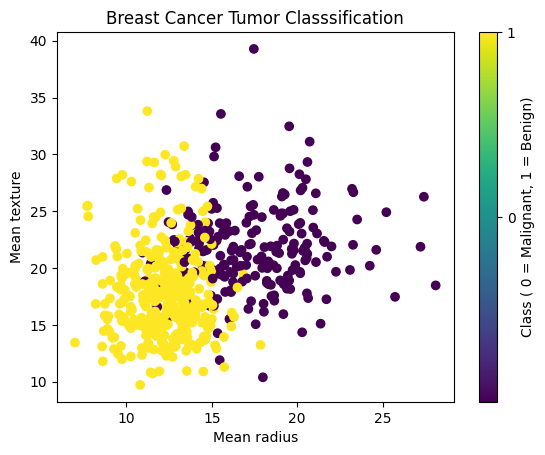

In [25]:
#Loading data
data = load_breast_cancer()
X, y = data.data, data.target
y = np.where(y == 0, -1, 1) #Preparing for boost
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')  # Pick two features to plot
plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

plt.show()

In [26]:
class SimpleKMeansPP:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.centroids = None
        self.labels_ = None

    def _initialize_centroids(self, X):
        n_samples, n_features = X.shape
        centroids = []
        
        #Pick the first centroid randomly
        first_idx = np.random.choice(n_samples)
        centroids.append(X[first_idx])

        #Pick the remaining centroids using probability proportional to distance²
        for _ in range(1, self.n_clusters):
            distances = np.array([min(np.linalg.norm(x - centroid)**2 for centroid in centroids) for x in X])
            probabilities = distances / distances.sum()
            next_idx = np.random.choice(n_samples, p=probabilities)
            centroids.append(X[next_idx])

        return np.array(centroids)

    def _compute_distances(self, X):
        distances = np.zeros((X.shape[0], self.n_clusters))
        for idx, centroid in enumerate(self.centroids):
            distances[:, idx] = np.linalg.norm(X - centroid, axis=1)
        return distances

    def fit(self, X):
        n_samples, n_features = X.shape

        # Initialize centroids using K-Means++
        self.centroids = self._initialize_centroids(X)

        for i in range(self.max_iter):
            # Assign clusters
            distances = self._compute_distances(X)
            labels = np.argmin(distances, axis=1)

            # Compute new centroids
            new_centroids = np.array([
                X[labels == j].mean(axis=0) if len(X[labels == j]) > 0 else self.centroids[j]
                for j in range(self.n_clusters)
            ])

            # Check convergence
            centroid_shift = np.linalg.norm(self.centroids - new_centroids)
            if centroid_shift < self.tol:
                break

            self.centroids = new_centroids

        self.labels_ = labels

    def predict(self, X):
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)

In [27]:
#Scalling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# Implementing our K-Means
kmeans_pp = SimpleKMeansPP(n_clusters=2)
kmeans_pp.fit(X_train_scaled)
test_preds = kmeans_pp.predict(X_test_scaled)
ari = adjusted_rand_score(y_test, test_preds)
print(f"Custom K-Means ARI on Test Set: {ari:.4f}")

Custom K-Means ARI on Test Set: 0.7351


In [29]:
# Implementing sklearn's K-Means
sklearn_kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
sklearn_kmeans.fit(X_train_scaled)
sklearn_preds = sklearn_kmeans.predict(X_test_scaled)
ari_sklearn = adjusted_rand_score(y_test, sklearn_preds)
print(f"Adjusted Rand Index (scikit-learn KMeans++): {ari_sklearn:.4f}")

Adjusted Rand Index (scikit-learn KMeans++): 0.7662


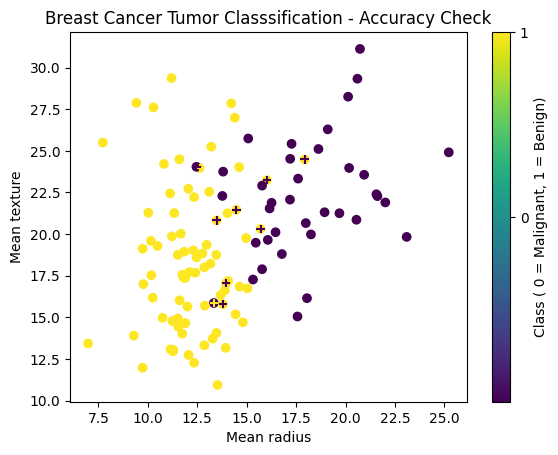

In [31]:
plt.scatter(X_test[:, 0], X_test[:, 1], c = test_preds)
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_test, marker = '+')

plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification - Accuracy Check')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

The accuracy of our model closely matches that of the sklearn equivalent, which shows our design is strong.

Visually, the plot shows that the clusters don’t perfectly align with the true labels, which is expected, since the plot only shows 2 out of 30 features, so much of the clustering decision-making is invisible in the 2D plot, and even though clustering is happening in high dimensions, the true classes (benign vs malignant) might not be perfectly separable by feature similarity alone.

A key takeaway from this Notebook is that unsupervised methods like K-Means can find structure in data, but they don’t optimize for the labels we care about. Also, in high-dimensional datasets, clustering performance may degrade because of overlapping classes, irrelevant features, and distance distortions.